**PROJET**

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random

# Partie 1

Question 1 : Génération de profils de vote

Nous générons un vote de référence ainsi que son opposé. Chaque votante est assignée à un groupe en fonction du paramètre de polarisation. Afin d’introduire de la variabilité, nous ajoutons un bruit aléatoire sur les votes en modifiant un certain nombre de positions tiré selon une loi binomiale.

In [2]:
def generation_profile_approbation(n, m, polarisation, p=0.1):

    profile = []
    vote = [np.random.randint(0, 2) for _ in range(m)]
    vote_opp = [1 - x for x in vote]

    if polarisation == 0:
        return [vote.copy() for _ in range(n)]
    
    if polarisation == 1:
        return [vote.copy() for _ in range(n // 2)] + [vote_opp.copy() for _ in range(n // 2)]
    
    # fonction qui prends en argument une liste de vote et modifie aléatoirement un nombre de vote selon une loi binomial avec comme paramètre p
    def ajouter_bruit(base):
        copie = base.copy()
        nb_modifs = np.random.binomial(m, p)
        indices = np.random.choice(m, nb_modifs, replace=False)
        for i in indices:
            copie[i] = 1 - copie[i]
        return copie

    # pour les n électeur on décide de qu'elle "côté de la polarisation" il va être puis on appliquqe ajouter_bruit
    for _ in range(n):
        r = np.random.rand()

        if r < polarisation / 2:
            profile.append(ajouter_bruit(vote_opp))

        elif r < polarisation:
            profile.append(ajouter_bruit(vote))

        else:
            profile.append(vote.copy())

    return profile

Question 2 : Génération de profils de vote avec ordre total. 
  
Nous introduisons un bruit en effectuant des échanges locaux dans le classement. Les positions modifiées sont tirées selon une loi normale centrée au milieu du classement. Ce choix reflète l’hypothèse que les votantes d’un même groupe partagent des préférences similaires concernant les candidates les plus et les moins appréciées, tandis que les désaccords portent davantage sur les candidates intermédiaires.

In [3]:
def generation_profile_ordretotal(n, m, polarisation, p=0.1, scale=1, spread=1):

    # classement de base
    vote = np.random.permutation(m).tolist()
    vote_opp = vote[::-1]

    # cas extrêmes
    if polarisation == 0:
        return [vote.copy() for _ in range(n)]

    if polarisation == 1:
        return [vote.copy() for _ in range(n // 2)] + [vote_opp.copy() for _ in range(n // 2)]

    def ajouter_bruit_ordre(base):
        copie = base.copy()
        nb_modifs = np.random.binomial(m, p)
        for _ in range(nb_modifs):
            # tirage autour du milieu
            i = int(np.random.normal(loc=m // 2, scale=scale))

            # premier indice
            i = max(0, min(m - 2, i))  # m-2 pour éviter le dépassement avec j

            # déplacement local
            diff = np.random.randint(1, spread + 1)
            j = min(m - 1, i + diff)

            copie[i], copie[j] = copie[j], copie[i]

        return copie

    profile = []

    for _ in range(n):
        r = np.random.rand()

        if r < polarisation / 2:
            profile.append(ajouter_bruit_ordre(vote_opp))

        elif r < polarisation:
            profile.append(ajouter_bruit_ordre(vote))

        else:
            profile.append(vote.copy())

    return profile

# Partie 2

Question 3 :

In [4]:
def calcul_d_approbation(p):
    d = {}

    m = len(p[0])
    for k in range(m):
        for j in range(k+1,m):
            n_kj=0
            n_jk=0
            for a in p:
                if a[k] ==1 and a[j] == 0: n_kj+=1
                elif a[k] == 0 and a[j] == 1: n_jk+=1
            d[(k,j)] = abs(n_kj - n_jk)
    return d



def calcul_d_ordre(p):
    d = {}
    n = len(p)
    m = len(p[0])
    rang = []
    for a in p:
        rank = {candidate: i for i, candidate in enumerate(a)}
        rang.append(rank)
    for k in range(m):
        for j in range(k+1, m):
            n_kj = sum([1 for rank in rang if rank[k] < rank[j]])
            n_jk = n - n_kj
            d[(k, j)] = abs(n_kj - n_jk)
    return d


Question 4:

$\varphi^2$ ne vérifie pas l'axiome 1.  
Soit $p_{a}$ tel que a = [0,...,0].  
Alors, pour tout k,l $\in$ {1,...,m} : $d_{c_k c_l}(p_{a})$ = 0. Cependant, $\varphi^2(p_{a})$ = 1 car il s'agit de la moyenne de 1.  
L'axiome 1 n'est donc pas verifié. 


$\varphi^2$ vérifie l'axiome 2.  
Soit $p$ un profil de vote et soit $k,l \in$ {1,...,m}. 
La permutation des candidats conduit à une simple permutation de l'ensemble des $d_{c_k c_l}(p)$. Seul l'ordre de somation est changé.  
On conclut que la somme $\sum_{\{c_k,c_l\}\in C^2} \frac{n - d_{c_k c_l}(p)}{n\binom{m}{2}}$ ne change pas entre $p$ et $p^\pi$

$\varphi^2$ vérifie l'axiome 3.  
Soit $p$ un profil de vote et soit $k,l \in$ {1,...,m}. 
Ici, les valeurs de $d_{c_k c_l}(p)$ ne changent pas selon la permutation des votantes.  
On conclut que $\varphi^2(p) = \varphi^2(p^\sigma)$.

$\varphi^2$ vérifie l'axiome 4.  
Soit $p$ un profil de vote et soit $i,j \in$ {1,...,m}.  
Soit k > 0.  
$n_{c_i c_j}(kp)$ = $kn_{c_i c_j}(p)$ car les nouveaux bulletins de votes sont identiques aux bulletins deja présent dans $p$.  
On a alors $d_{c_i c_j}(kp) = |n_{c_i c_j}(kp) - n_{c_j c_ji}(kp)| = k|n_{c_i c_j}(p) - n_{c_j c_ji}(p)| = kd_{c_i c_j}(p)$
On a finalement :  
   
$\varphi^2(kp) = \sum_{\{c_i,c_j\}\in C^2} \frac{kn - kd_{c_i c_j}(p)}{kn\binom{m}{2}} = \sum_{\{c_i,c_j\}\in C^2} \frac{n - d_{c_i c_j}(p)}{n\binom{m}{2}} = \varphi^2(p)$.


Question 5 :

In [5]:
def phi2_approbation(p):
    n = len(p)
    m = len(p[0])
    d = calcul_d_approbation(p)
    tot = 0
    for i in d.values():
        tot += (n-i)/n
    return tot/(math.factorial(m)/(math.factorial(m-2)*2))

def phi2_ordre(p):
    n = len(p)
    m = len(p[0])
    d = calcul_d_ordre(p)
    tot = 0
    for i in d.values():
        tot += (n-i)/n
    return tot/(math.factorial(m)/(math.factorial(m-2)*2))


Question 6 : 

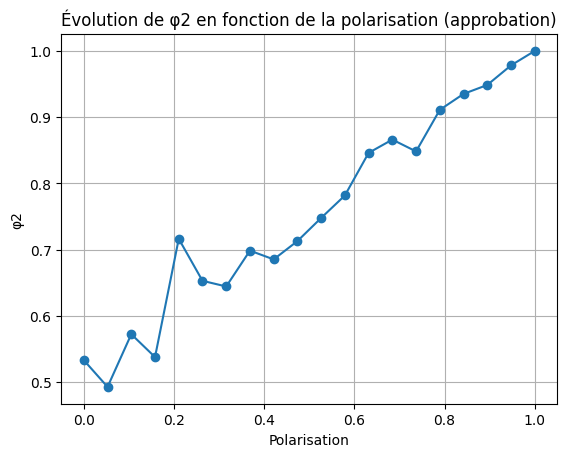

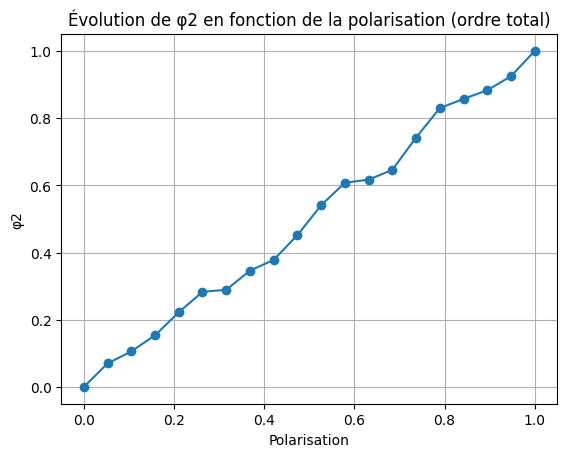

In [6]:
polarisations = np.linspace(0, 1, 20)
phi2_approbation_val = []

for pol in polarisations:
    profile = generation_profile_approbation(n=1000, m=10, polarisation=pol, p=0.1)
    phi2_approbation_val.append(phi2_approbation(profile))

plt.plot(polarisations, phi2_approbation_val, marker='o')
plt.title('Évolution de φ2 en fonction de la polarisation (approbation)')
plt.xlabel('Polarisation')
plt.ylabel('φ2')
plt.grid()
plt.show()


phi2_ordre_val = []
for pol in polarisations:
    profile = generation_profile_ordretotal(n=1000, m=10, polarisation=pol, p=0.1, scale=1, spread=1)
    phi2_ordre_val.append(phi2_ordre(profile))

plt.plot(polarisations, phi2_ordre_val, marker='o')
plt.title('Évolution de φ2 en fonction de la polarisation (ordre total)')
plt.xlabel('Polarisation')
plt.ylabel('φ2')
plt.grid()
plt.show()

Nous observons que la mesure φ₂ augmente globalement avec le niveau de polarisation. Lorsque la polarisation est faible, les profils sont homogènes et $\varphi^{2}$ est proche de 0. À mesure que la polarisation augmente, des groupes opposés apparaissent, ce qui augmente les désaccords entre paires de candidates, et donc la valeur de $\varphi^{2}$.  
On observe toutefois que la mesure n’est pas parfaitement monotone en raison du bruit introduit dans la génération des profils.

# Partie 3

Question 7 :

Soit $a_{v_k}, a_{v_l}, a_{v_j} \in A$.  
  
Montrons la positivité :   
$d_H(a_{v_k}, a_{v_l})$ est une somme de 1 et 0. On a donc bien $d_H(a_{v_k}, a_{v_l}) ≥ 0$.  
$d_S(≺_{v_k}, ≺_{v_l})$ est une somme valeur absolue. On a donc bien $d_S(≺_{v_k}, ≺_{v_l}) ≥ 0$.  
La positivité est bien respectée pour ces deux applications.  

Montrons la séparation.  
$d_H(a_{v_k}, a_{v_l}) = 0 \Leftrightarrow \sum_{i=1}^m \mathbf{1}_{a_{v_k}[i] \ne a_{v_l}[i]} = 0 \Leftrightarrow \forall i\in $ {1,...,m} : $ \mathbf{1}_{a_{v_k}[i] \ne a_{v_l}[i]} = 0 \Leftrightarrow \forall i\in $ {1,...,m} : $ a_{v_k}[i] = a_{v_l}[i] \Leftrightarrow a_{v_k} = a_{v_l}$.  
$d_S(≺_{v_k}, ≺_{v_l}) = 0 \Leftrightarrow \sum_{i=1}^m |r_{v_k}(i) - r_{v_l}(i)| = 0 \Leftrightarrow \forall i\in $ {1,...,m} : $ |r_{v_k}(i) - r_{v_l}(i)| = 0 \Leftrightarrow \forall i\in $ {1,...,m} : $ r_{v_k}(i) = r_{v_l}(i) \Leftrightarrow r_{v_k} = r_{v_l}$.  
La séparation est bien respectée pour ces deux applications.  

Montrons la symétrie.  
$d_H(a_{v_k}, a_{v_l}) = \sum_{i=1}^m \mathbf{1}_{a_{v_k}[i] \ne a_{v_l}[i]} = \sum_{i=1}^m \mathbf{1}_{a_{v_l}[i] \ne a_{v_k}[i]} = d_H(a_{v_l}, a_{v_k})$ grâce à la symétrie de l'indicatrice.  
$d_S(≺_{v_k}, ≺_{v_l}) = \sum_{i=1}^m |r_{v_k}(i) - r_{v_l}(i)| = \sum_{i=1}^m |r_{v_l}(i) - r_{v_k}(i)| = d_S(≺_{v_l}, ≺_{v_k})$ grâce à la symétrie de la valeur absolue.  
La symétrie est bien respectée pour ces deux applications.  

Montrons l'inégalité triangulaire.  
Tout d'abord, si $\mathbf{1}_{a_{v_k}[i] \ne a_{v_l}[i]} = 1$, alors :  
Si $\mathbf{1}_{a_{v_k}[i] \ne a_{v_j}[i]} = 0$ Alors $\mathbf{1}_{a_{v_j}[i] \ne a_{v_l}[i]} = 1$.  
Et si $\mathbf{1}_{a_{v_j}[i] \ne a_{v_l}[i]} = 0$ Alors $\mathbf{1}_{a_{v_k}[i] \ne a_{v_j}[i]} = 1$.  
On a donc $\mathbf{1}_{a_{v_k}[i] \ne a_{v_l}[i]} \leq \mathbf{1}_{a_{v_k}[i] \ne a_{v_j}[i]} + \mathbf{1}_{a_{v_j}[i] \ne a_{v_l}[i]}$.  

On montre alors :  
$d_H(a_{v_k}, a_{v_l}) = \sum_{i=1}^m \mathbf{1}_{a_{v_k}[i] \ne a_{v_l}[i]} \leq \sum_{i=1}^m (\mathbf{1}_{a_{v_k}[i] \ne a_{v_j}[i]} + \mathbf{1}_{a_{v_j}[i] \ne a_{v_l}[i]}) = \sum_{i=1}^m \mathbf{1}_{a_{v_k}[i] \ne a_{v_j}[i]} + \sum_{i=1}^m \mathbf{1}_{a_{v_j}[i] \ne a_{v_l}[i]} = d_H(a_{v_k}, a_{v_j}) + d_H(a_{v_j}, a_{v_l})$.  

De plus, grace à l'inégalité triangulaire de la valeure absolue :  
$d_S(≺_{v_k}, ≺_{v_l}) = \sum_{i=1}^m |r_{v_k}(i) - r_{v_l}(i)| = \sum_{i=1}^m |r_{v_k}(i) - r_{v_j}(i) + r_{v_j}(i)- r_{v_l}(i)| \leq \sum_{i=1}^m(|r_{v_k}(i) - r_{v_j}(i)| + |r_{v_j}(i)- r_{v_l}(i)|) =\sum_{i=1}^m |r_{v_k}(i) - r_{v_j}(i)| + \sum_{i=1}^m |r_{v_j}(i) - r_{v_l}(i)| = d_S(≺_{v_k}, ≺_{v_j}) + d_S(≺_{v_j}, ≺_{v_l})$.  
L'inégalité triangulaire est bien respectée pour ces deux applications.  

On conclut que ces deux applications sont des distances.

Question 8 :

In [7]:
def distance_hamming(a1, a2):
    return np.sum(np.array(a1) != np.array(a2))

def distance_spearman(s1, s2):
    rank = {c: i for i, c in enumerate(s1)}
    rank2 = {c: i for i, c in enumerate(s2)}
    return sum(abs(rank[c] - rank2[c]) for c in rank)


Question 9:

$\varphi_{d_H}$ vérifie les axiomes 1, 2, 3 et 4.

On a:
$$
\varphi_{d_H}(p)=\frac{2}{nm}\left(u_1^*(p)-u_2^*(p)\right),
$$
où
$$
u_1^*(p)=\min_{a\in\mathcal A}\sum_{a'\in p} d_H(a,a')
\qquad\text{et}\qquad
u_2^*(p)=\min_{a_1,a_2\in\mathcal A}\sum_{a'\in p}\min\{d_H(a_1,a'),d_H(a_2,a')\}.
$$


Axiome 1

Montrons que $\varphi_{d_H}(p)\in[0,1]$,
on a toujours
$$
u_2^*(p)\leq u_1^*(p),
$$
car en choisissant $a_1=a_2=a^*$ on a un coût égale à $u_1^*(p)$, donc comme $u_2^*(p)$ est un minimum sur tous les couples $(a_1,a_2)$, on a nécessairement $u_2^*(p)\leq u_1^*(p)$. Donc
$$
u_1^*(p)-u_2^*(p)\geq 0 \iff \varphi_{d_H}(p)\geq 0.
$$

Pour majorer $\varphi_{d_H}(p)$, on remarque que pour tout profil $p$ on a
$$
u_1^*(p)\leq \frac{nm}{2}.
$$
Car pour chaque candidate $c_j$, le bulletin $a$ qui minimise
$$
\sum_{a'\in p} d_H(a,a')
$$
choisit en position $j$ la valeur majoritaire parmi les bulletins de $p$. Le nombre d'erreurs sur cette coordonnée est donc au plus $\frac n2$. En sommant sur les $m$ coordonnées, on obtient
$$
u_1^*(p)\leq m\times \frac n2=\frac{nm}{2}.
$$
Comme de plus $u_2^*(p)\geq 0$, on a
$$
u_1^*(p)-u_2^*(p)\leq \frac{nm}{2},
$$
donc
$$
\varphi_{d_H}(p)\leq \frac{2}{nm}\times \frac{nm}{2}=1.
$$
On a donc bien
$$
\varphi_{d_H}(p)\in[0,1].
$$

Montrons maintenant que $\varphi_{d_H}(p)=0$ si et seulement si $p=p_a$.

Or
$$
u_1^*(p_a)=0
$$
en prenant $a$ dans la définition de $u_1^*(p)$, et
$$
u_2^*(p_a)=0
$$
en prenant $a_1=a_2=a$ dans la définition de $u_2^*(p)$. Donc
$$
\varphi_{d_H}(p_a)=\frac{2}{nm}(0-0)=0.
$$

Réciproquement, supposons que $\varphi_{d_H}(p)=0$. Alors
$$
u_1^*(p)=u_2^*(p).
$$
Soit $a^*$ réalisant le minimum dans la définition de $u_1^*(p)$. Si tous les bulletins de $p$ sont égaux à $a^*$, alors $p=p_{a^*}$.

Supposons qu'il existe $a'\in p$ tel que $a'\neq a^*$. Alors
$$
d_H(a^*,a')>0.
$$
En prenant $a_1=a^*$ et $a_2=a'$, on a pour le bulletin $a'$ :
$$
\min\{d_H(a_1,a'),d_H(a_2,a')\}=\min\{d_H(a^*,a'),0\}=0,
$$
alors que dans $u_1^*(p)$ sa contribution vaut $d_H(a^*,a')>0$. Donc on obtient strictement moins que $u_1^*(p)$, ce qui contredit
$$
u_1^*(p)=u_2^*(p).
$$
Ainsi, tous les bulletins de $p$ sont identiques, donc
$$
p=p_a.
$$
On a donc montré
$$
\varphi_{d_H}(p)=0 \iff p=p_a.
$$

Montrons maintenant que $\varphi_{d_H}(p)=1$ si et seulement si $p=p_{a,\bar a}$.

Soit $p_{a,\bar a}$ un profil contenant $\frac n2$ copies de $a$ et $\frac n2$ copies de $\bar a$. Alors
$$
u_2^*(p_{a,\bar a})=0
$$
en prenant $a_1=a$ et $a_2=\bar a$, puisque chaque bulletin du profil est alors à distance nulle de l'un des deux.

Calculons $u_1^*(p_{a,\bar a})$. Pour chaque candidate $c_j$, il y a exactement $\frac n2$ bulletins qui valent $0$ en position $j$ et $\frac n2$ bulletins qui valent $1$ en position $j$. Donc, quel que soit le choix de la valeur en position $j$ du bulletin $a$, on commet exactement $\frac n2$ erreurs sur cette coordonnée. En sommant sur les $m$ coordonnées, on obtient
$$
u_1^*(p_{a,\bar a})=\frac{nm}{2}.
$$
Ainsi
$$
\varphi_{d_H}(p_{a,\bar a})
=\frac{2}{nm}\left(\frac{nm}{2}-0\right)=1.
$$

Réciproquement, supposons que $\varphi_{d_H}(p)=1$. Alors
$$
u_1^*(p)-u_2^*(p)=\frac{nm}{2}.
$$
Or on a toujours
$$
u_1^*(p)\leq \frac{nm}{2}
\qquad\text{et}\qquad
u_2^*(p)\geq 0.
$$
Donc nécessairement
$$
u_1^*(p)=\frac{nm}{2}
\qquad\text{et}\qquad
u_2^*(p)=0.
$$

La condition $u_2^*(p)=0$ signifie qu'il existe $a_1,a_2\in\mathcal A$ tels que pour tout $a'\in p$,
$$
\min\{d_H(a_1,a'),d_H(a_2,a')\}=0.
$$
Autrement dit, chaque bulletin $a'$ du profil est égal soit à $a_1$, soit à $a_2$. Le profil ne contient donc qu'au plus deux bulletins distincts.

D'autre part, la condition
$$
u_1^*(p)=\frac{nm}{2}
$$
signifie que, pour chaque coordonnée, même le meilleur choix possible commet exactement $\frac n2$ erreurs. Donc, pour chaque candidate $c_j$, il y a exactement autant de $0$ que de $1$ parmi les bulletins du profil.

Comme le profil ne contient qu'au plus deux bulletins distincts et que, sur chaque coordonnée, on a moitié $0$ et moitié $1$, ces deux bulletins doivent être opposés coordonnée par coordonnée. Donc il existe $a\in\mathcal A$ tel que les deux bulletins soient $a$ et $\bar a$, chacun apparaissant $\frac n2$ fois. Ainsi
$$
p=p_{a,\bar a}.
$$
On a donc montré
$$
\varphi_{d_H}(p)=1 \iff p=p_{a,\bar a}.
$$

Ainsi, $\varphi_{d_H}$ vérifie l'axiome 1.

Axiome 2

Soit $\pi$ une permutation sur $\{1,\dots,m\}$. Passer de $p$ à $p^\pi$ revient à permuter de la même façon les coordonnées de tous les bulletins. Or pour tous $a,b\in\mathcal A$, on a
$$
d_H(a^\pi,b^\pi)=d_H(a,b),
$$
car la distance de Hamming ne dépend que du nombre de coordonnées différentes. Donc les quantités minimisées dans $u_1^*(p)$ et $u_2^*(p)$ ne changent pas si l'on remplace $p$ par $p^\pi$. Ainsi
$$
u_1^*(p^\pi)=u_1^*(p)
\qquad\text{et}\qquad
u_2^*(p^\pi)=u_2^*(p),
$$
d'où
$$
\varphi_{d_H}(p^\pi)=\varphi_{d_H}(p).
$$
Donc $\varphi_{d_H}$ vérifie l'axiome 2.

Axiome 3

Soit $\sigma$ une permutation sur $\{1,\dots,n\}$. Passer de $p$ à $\sigma p$ revient seulement à permuter l'ordre des bulletins dans le profil. Or dans les définitions de $u_1^*(p)$ et $u_2^*(p)$, on somme sur tous les bulletins du profil, donc changer leur ordre ne change pas la valeur de la somme. Ainsi
$$
u_1^*(\sigma p)=u_1^*(p)
\qquad\text{et}\qquad
u_2^*(\sigma p)=u_2^*(p),
$$
puis
$$
\varphi_{d_H}(\sigma p)=\varphi_{d_H}(p).
$$
Donc $\varphi_{d_H}$ vérifie l'axiome 3.

Axiome 4

Soit $k\in\mathbb N^*$. Dans le profil $kp$, chaque bulletin de $p$ est répété $k$ fois. Donc, pour tout $a\in\mathcal A$,
$$
\sum_{a'\in kp} d_H(a,a') = k\sum_{a'\in p} d_H(a,a').
$$
En prenant le minimum sur $a\in\mathcal A$, on obtient
$$
u_1^*(kp)=k\,u_1^*(p).
$$
De même,
$$
u_2^*(kp)=k\,u_2^*(p).
$$
Comme le profil $kp$ contient $kn$ bulletins, on a
$$
\varphi_{d_H}(kp)
=\frac{2}{(kn)m}\left(k\,u_1^*(p)-k\,u_2^*(p)\right)
=\frac{2}{nm}\left(u_1^*(p)-u_2^*(p)\right)
=\varphi_{d_H}(p).
$$
Donc $\varphi_{d_H}$ vérifie l'axiome 4.

On conclut que $\varphi_{d_H}$ vérifie les axiomes 1, 2, 3 et 4.

# Question 10 :

Soit $p=(a^{(1)},\dots,a^{(n)})\in \mathcal A^n$. On cherche à calculer efficacement
$$
u_1^*(p)=\min_{a\in\mathcal A}\sum_{t=1}^n d_H(a,a^{(t)}).
$$
Pour tout bulletin $a\in\mathcal A$ et tout $t\in\{1,\dots,n\}$, on a
$$
d_H(a,a^{(t)})=\sum_{j=1}^m \mathbf{1}_{a[j]\neq a^{(t)}[j]}.
$$
Donc
$$
\sum_{t=1}^n d_H(a,a^{(t)})
=
\sum_{t=1}^n\sum_{j=1}^m \mathbf{1}_{a[j]\neq a^{(t)}[j]}
=
\sum_{j=1}^m\sum_{t=1}^n \mathbf{1}_{a[j]\neq a^{(t)}[j]}.
$$

Ainsi, le coût total se décompose coordonnée par coordonnée. On peut donc minimiser séparément la contribution de chaque candidate $c_j$.

Fixons une candidate $c_j$. On note
$$
n_j^1 = |\{t\in\{1,\dots,n\}\mid a^{(t)}[j]=1\}|
\qquad\text{et}\qquad
n_j^0 = |\{t\in\{1,\dots,n\}\mid a^{(t)}[j]=0\}|.
$$
On a bien $n_j^0+n_j^1=n$.

Si l’on choisit $a[j]=1$, alors le nombre d’erreurs commises sur la coordonnée $j$ est exactement $n_j^0$, puisque l’on diffère des bulletins qui valent $0$ en position $j$.

Si l’on choisit $a[j]=0$, alors le nombre d’erreurs commises sur la coordonnée $j$ est exactement $n_j^1$.

Le meilleur choix pour la coordonnée $j$ est donc de prendre la valeur majoritaire parmi les bulletins du profil. La contribution minimale de cette coordonnée vaut alors
$$
\min(n_j^0,n_j^1).
$$

En sommant sur toutes les coordonnées, on obtient
$$
u_1^*(p)=\sum_{j=1}^m \min(n_j^0,n_j^1).
$$

Un bulletin optimal $a^*$ est donc obtenu en posant, pour tout $j\in\{1,\dots,m\}$,
$$
a^*[j]=
\begin{cases}
1 & \text{si } n_j^1>n_j^0,\\
0 & \text{si } n_j^0>n_j^1,\\
0 \text{ ou } 1 & \text{si } n_j^0=n_j^1.
\end{cases}
$$

On en déduit que le calcul de $u_1^*(p)$ peut se faire efficacement : il suffit de parcourir les $m$ coordonnées et, pour chacune d’elles, de compter le nombre de $0$ et de $1$ parmi les $n$ bulletins. La complexité est donc en $O(nm)$, ce qui est polynomial, contrairement à une recherche sur les $2^m$ bulletins possibles.

# Question 11 :

Soit $p=(\succ_1,\dots,\succ_n)\in \mathcal L^n$. On cherche à calculer efficacement
$$
u_1^*(p)=\min_{\succ\in\mathcal L}\sum_{t=1}^n d_S(\succ,\succ_t),
$$
où
$$
d_S(\succ,\succ_t)=\sum_{i=1}^m \left|r_{\succ}(c_i)-r_{\succ_t}(c_i)\right|.
$$

Dans le cas des ordres totaux, on ne peut pas traiter les candidates indépendamment comme pour les votes par approbation. En effet, un bulletin de consensus doit être un ordre total, donc une permutation des rangs $1,\dots,m$ : si une candidate est placée au rang $k$, aucune autre candidate ne peut être placée à ce même rang.

Pour une candidate $c_i$ et un rang $k\in\{1,\dots,m\}$, on définit
$$
w_{i,k}=\sum_{t=1}^n \left|k-r_{\succ_t}(c_i)\right|.
$$
Ce qui représente le coût total obtenu si l'on décide de placer la candidate $c_i$ au rang $k$ dans le bulletin de consensus.

On construit alors un graphe biparti dont :
- la partie gauche est l'ensemble des candidates $\{c_1,\dots,c_m\}$ ;
- la partie droite est l'ensemble des rangs $\{1,\dots,m\}$ ;
- l'arête reliant $c_i$ à $k$ est de poids $w_{i,k}$.

Un couplage parfait dans ce graphe associe chaque candidate à un rang unique et chaque rang à une candidate unique. Il définit donc exactement un ordre total sur les candidates, et réciproquement tout ordre total correspond à un couplage parfait comme celui-là.

Soit $\succ\in\mathcal L$. Le couplage parfait associé relie chaque candidate $c_i$ au rang $r_{\succ}(c_i)$. Son poids total vaut alors
$$
\sum_{i=1}^m w_{i,r_{\succ}(c_i)}
=
\sum_{i=1}^m \sum_{t=1}^n \left|r_{\succ}(c_i)-r_{\succ_t}(c_i)\right|.
$$
En échangeant les sommes, on obtient
$$
\sum_{t=1}^n \sum_{i=1}^m \left|r_{\succ}(c_i)-r_{\succ_t}(c_i)\right|
=
\sum_{t=1}^n d_S(\succ,\succ_t).
$$

Ainsi, minimiser
$$
\sum_{t=1}^n d_S(\succ,\succ_t)
$$
sur tous les ordres totaux $\succ$ revient exactement à chercher un couplage parfait de poids minimum dans ce graphe biparti.

On en déduit que le calcul de $u_1^*(p)$ peut se faire efficacement en construisant la matrice de coûts
$$
W=(w_{i,k})_{1\leq i,k\leq m},
$$
puis en résolvant le problème d'affectation correspondant.

Dans `scipy`, la fonction `scipy.optimize.linear_sum_assignment` permet de résoudre le problème d'affectation associé à la matrice de coûts $W$. D'après la documentation, elle résout le *linear sum assignment problem*, c'est-à-dire un problème de couplage de poids minimal dans un graphe biparti, à partir d'une matrice de coûts. Ce choix convient ici puisque l'on cherche à affecter chaque candidate à un rang unique, et chaque rang à une candidate unique.

La construction de la matrice $W$ demande de calculer $m^2$ coefficients, et chacun d'eux s'obtient en sommant sur les $n$ votantes, ce qui donne un coût en $O(nm^2)$. La résolution du problème d'affectation sur une matrice dense de taille $m\times m$ est ensuite en $O(m^3)$. On peut ainsi retenir une complexité totale de l'ordre de
$$
O(nm^2+m^3).
$$

On obtient ainsi une méthode polynomiale pour calculer $u_1^*(p)$, nettement plus efficace qu'une recherche sur les $m!$ ordres totaux possibles.

Question 12 :

In [8]:
from scipy.optimize import linear_sum_assignment

In [49]:
def u1_approbation(p):
    n = len(p)
    m = len(p[0])
    u1 = 0
    for j in range(m):
        n_j1 = sum(a[j] for a in p)
        n_j0 = n - n_j1
        u1 += min(n_j0, n_j1)
    return u1

def u1_ordre(p):
    m = len(p[0])

    # matrice des coûts
    W = np.zeros((m, m), dtype=int)

    ranks = []
    for a in p:
        rank = {candidate : i for i,candidate in enumerate(a)}
        ranks.append(rank)

    for i in range(m):
        for k in range(m):
            W[i,k] = sum(abs(k - rank[i]) for rank in ranks)

    # problème de couplage parfait
    row_ind, col_ind = linear_sum_assignment(W)

    return int(W[row_ind, col_ind].sum())


Question 13 :

In [ ]:
def u2_approbation(p):
    a1 = random.choice(p) 
    a2 = random.choice([a for a in p if a != a1]) # Centroides differents
    

    while True :
        cluster_a1 = []
        cluster_a2 = []
        for a in p :
            if distance_hamming(a, a1) < distance_hamming(a, a2):
                cluster_a1.append(a)
            else:
                cluster_a2.append(a)

        a1_new = min(cluster_a1, key = lambda x : sum(distance_hamming(a, x) for a in cluster_a1))
        a2_new = min(cluster_a2, key = lambda x : sum(distance_hamming(a, x) for a in cluster_a2))

        if a1_new == a1 and a2_new == a2 :
            break

        a1, a2 = a1_new, a2_new

    return sum(distance_hamming(a, a1) for a in cluster_a1) + sum(distance_hamming(a, a2) for a in cluster_a2)

def u2_ordre(p):
    a1 = random.choice(p) 
    a2 = random.choice([a for a in p if a != a1]) # Centroides differents
    

    while True :
        cluster_a1 = []
        cluster_a2 = []
        for a in p :
            if distance_spearman(a, a1) < distance_spearman(a, a2):
                cluster_a1.append(a)
            else:
                cluster_a2.append(a)

        a1_new = min(cluster_a1, key = lambda x : sum(distance_spearman(a, x) for a in cluster_a1))
        a2_new = min(cluster_a2, key = lambda x : sum(distance_spearman(a, x) for a in cluster_a2))

        if a1_new == a1 and a2_new == a2 :
            break

        a1, a2 = a1_new, a2_new

    return sum(distance_spearman(a, a1) for a in cluster_a1) + sum(distance_spearman(a, a2) for a in cluster_a2)
